In [1]:
!pip install segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.8 MB/s eta 0:00:00


In [3]:
!pip install kaggle
import torch
print(torch.__version__)


2.11.0+cpu


In [4]:
!pip install segmentation-models-pytorch albumentations torch torchvision

In [1]:
!git clone https://github.com/alexgkendall/SegNet-Tutorial.git

Cloning into 'SegNet-Tutorial'...
remote: Enumerating objects: 2785, done.
remote: Total 2785 (delta 0), reused 0 (delta 0), pack-reused 2785 (from 1)
Receiving objects: 100% (2785/2785), 340.84 MiB | 27.61 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [2]:
import os

for item in os.listdir('SegNet-Tutorial'):
    print(item)


docker
.gitattributes
Example_Models
.gitignore
README.md
.git
Models
CamVid
Scripts


In [3]:
for item in os.listdir('SegNet-Tutorial/CamVid'):
    print(item)

val
val.txt
valannot
train
test.txt
trainannot
testannot
test
train.txt


In [4]:
import os

train_images = os.listdir('SegNet-Tutorial/CamVid/train')
train_masks = os.listdir('SegNet-Tutorial/CamVid/trainannot')

print(f"Number of training images: {len(train_images)}")
print(f"Number of training masks: {len(train_masks)}")
print(f"Sample image: {train_images[0]}")
print(f"Sample mask: {train_masks[0]}")

Number of training images: 367
Number of training masks: 367
Sample image: 0006R0_f01140.png
Sample mask: 0006R0_f01140.png


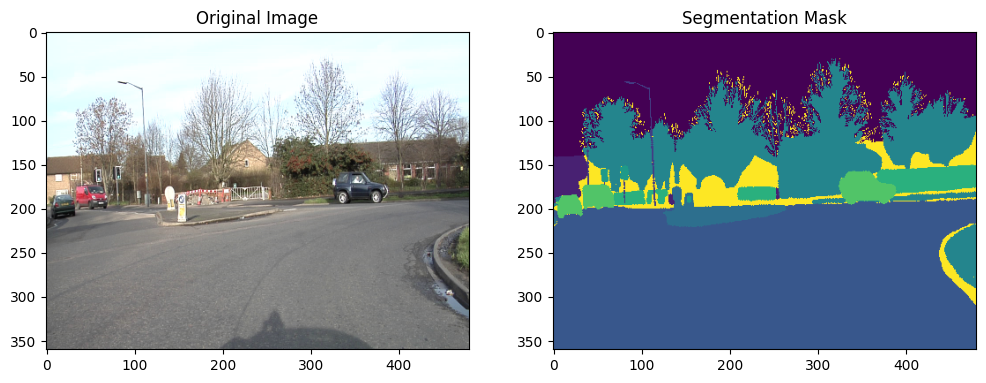

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = Image.open('SegNet-Tutorial/CamVid/train/0006R0_f01140.png')
mask = Image.open('SegNet-Tutorial/CamVid/trainannot/0006R0_f01140.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[1].imshow(mask)
axes[1].set_title('Segmentation Mask')
plt.show()

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np

class CamVidDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        image = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])(image)

        mask = transforms.Compose([
            transforms.Resize((256, 256), interpolation=Image.NEAREST),
            transforms.PILToTensor()
        ])(mask).squeeze(0).long()

        return image, mask

train_dataset = CamVidDataset(
    'SegNet-Tutorial/CamVid/train',
    'SegNet-Tutorial/CamVid/trainannot'
)

val_dataset = CamVidDataset(
    'SegNet-Tutorial/CamVid/val',
    'SegNet-Tutorial/CamVid/valannot'
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 367
Validation samples: 101


In [8]:
!pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=32,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")
print("Model loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Using device: cuda
Model loaded.


In [9]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
    return total_loss / len(loader)

print("Starting training...\n")
for epoch in range(1, 6):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_epoch(model, val_loader, criterion)
    print(f"Epoch {epoch} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")

print("\nTraining complete.")

Starting training...

Epoch 1 | Train Loss: 2.968 | Val Loss: 2.371
Epoch 2 | Train Loss: 2.189 | Val Loss: 1.991
Epoch 3 | Train Loss: 1.707 | Val Loss: 1.593
Epoch 4 | Train Loss: 1.365 | Val Loss: 1.279
Epoch 5 | Train Loss: 1.108 | Val Loss: 1.089

Training complete.


In [10]:
def compute_iou(model, loader, num_classes=32):
    model.eval()
    intersection = torch.zeros(num_classes)
    union = torch.zeros(num_classes)

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)
                intersection[cls] += (pred_cls & mask_cls).sum().item()
                union[cls] += (pred_cls | mask_cls).sum().item()

    iou = intersection / (union + 1e-6)
    return iou

iou_scores = compute_iou(model, val_loader)
mean_iou = iou_scores.mean().item()
print(f"Mean IoU: {mean_iou:.3f}")
print("\nPer class IoU:")
for i, score in enumerate(iou_scores):
    print(f"Class {i}: {score:.3f}")

Mean IoU: 0.118

Per class IoU:
Class 0: 0.920
Class 1: 0.782
Class 2: 0.000
Class 3: 0.767
Class 4: 0.056
Class 5: 0.782
Class 6: 0.000
Class 7: 0.000
Class 8: 0.451
Class 9: 0.004
Class 10: 0.000
Class 11: 0.001
Class 12: 0.000
Class 13: 0.000
Class 14: 0.000
Class 15: 0.000
Class 16: 0.000
Class 17: 0.000
Class 18: 0.000
Class 19: 0.000
Class 20: 0.000
Class 21: 0.000
Class 22: 0.000
Class 23: 0.000
Class 24: 0.000
Class 25: 0.000
Class 26: 0.000
Class 27: 0.000
Class 28: 0.000
Class 29: 0.000
Class 30: 0.000
Class 31: 0.000


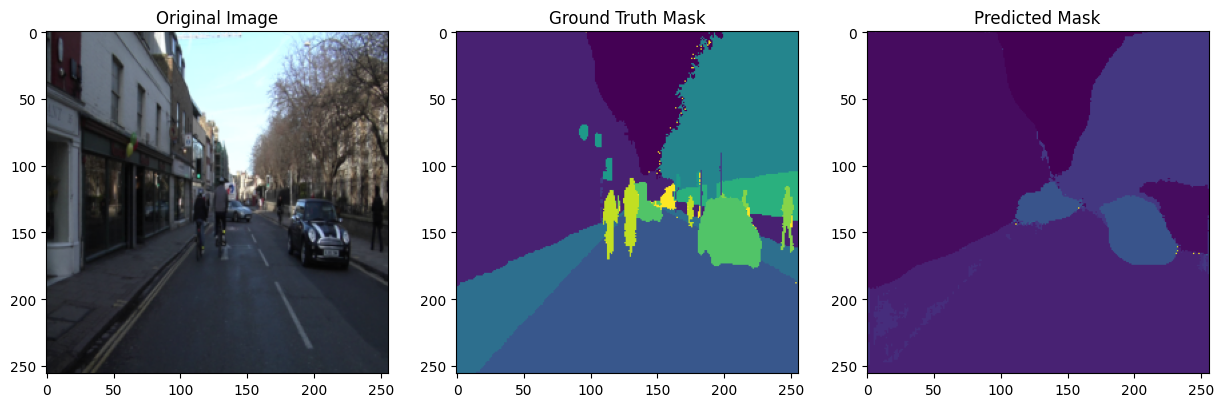

In [11]:
from IPython.display import display
import matplotlib.pyplot as plt

model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(images[0].cpu().permute(1,2,0) * 0.5 + 0.5)
axes[0].set_title('Original Image')
axes[1].imshow(masks[0].cpu())
axes[1].set_title('Ground Truth Mask')
axes[2].imshow(preds[0].cpu())
axes[2].set_title('Predicted Mask')
plt.show()